In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
tsla = pd.read_csv("../data/processed/TSLA_cleaned.csv", index_col=0, parse_dates=True)
bnd = pd.read_csv("../data/processed/BND_cleaned.csv", index_col=0, parse_dates=True)
spy = pd.read_csv("../data/processed/SPY_cleaned.csv", index_col=0, parse_dates=True)

tsla.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000
2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500
2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500
2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000
2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500


In [3]:
prices = pd.DataFrame({
    "TSLA": tsla["Adj Close"],
    "BND": bnd["Adj Close"],
    "SPY": spy["Adj Close"]
})

prices = prices.dropna()

prices.head()

,TSLA,BND,SPY
Date,,,
2015-01-02,14.620667,59.205685,169.687851
2015-01-05,14.006000,59.377590,166.623306
2015-01-06,14.085333,59.549522,165.053925
2015-01-07,14.063333,59.585300,167.110672
2015-01-08,14.041333,59.492199,170.076065


In [4]:
daily_returns = prices.pct_change().dropna()

daily_returns.head()

,TSLA,BND,SPY
Date,,,
2015-01-05,-0.042041,0.002904,-0.018060
2015-01-06,0.005664,0.002896,-0.009419
2015-01-07,-0.001562,0.000601,0.012461
2015-01-08,-0.001564,-0.001562,0.017745
2015-01-09,-0.018802,0.001686,-0.008013


In [5]:
forecast = pd.read_csv("../data/processed/tsla_future_forecast.csv", index_col=0, parse_dates=True)

forecast.head()

,Forecasted_TSLA_Price,Lower_95_CI,Upper_95_CI
2026-07-01,420.376815,406.050262,434.703368
2026-07-02,420.003660,399.987584,440.019736
2026-07-03,419.683476,395.250499,444.116452
2026-07-06,419.722168,391.636307,447.808028
2026-07-07,419.752670,388.481898,451.023442


In [6]:
last_actual_tsla_price = prices["TSLA"].iloc[-1]
final_forecast_tsla_price = forecast["Forecasted_TSLA_Price"].iloc[-1]

tsla_forecast_return = (final_forecast_tsla_price - last_actual_tsla_price) / last_actual_tsla_price

print("Last actual TSLA price:", last_actual_tsla_price)
print("Final forecasted TSLA price:", final_forecast_tsla_price)
print("TSLA forecasted return:", tsla_forecast_return)

Last actual TSLA price: 420.6000061035156
Final forecasted TSLA price: 419.756911729403
TSLA forecasted return: -0.002004503951208077


In [7]:
historical_annual_returns = daily_returns.mean() * 252

historical_annual_returns

TSLA    0.455938
BND     0.019888
SPY     0.144950
dtype: float64

In [8]:
expected_returns = pd.Series({
    "TSLA": tsla_forecast_return,
    "BND": historical_annual_returns["BND"],
    "SPY": historical_annual_returns["SPY"]
})

expected_returns

TSLA   -0.002005
BND     0.019888
SPY     0.144950
dtype: float64

In [9]:
cov_matrix = daily_returns.cov() * 252

cov_matrix

,TSLA,BND,SPY
TSLA,0.326846,0.001782,0.049815
BND,0.001782,0.002823,0.001083
SPY,0.049815,0.001083,0.031162


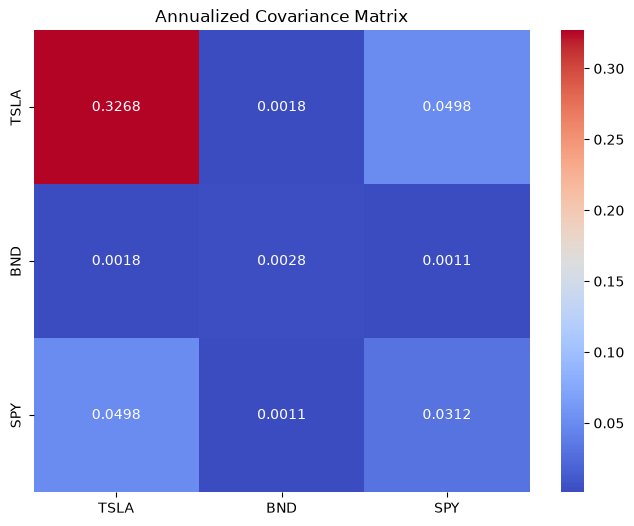

In [10]:
os.makedirs("../reports/figures", exist_ok=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, cmap="coolwarm", fmt=".4f")
plt.title("Annualized Covariance Matrix")
plt.savefig("../reports/figures/covariance_matrix_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

The covariance matrix shows how the returns of TSLA, BND, and SPY move together. TSLA has the highest variance, confirming that it is the riskiest asset. BND has the lowest variance, showing that it is the most stable asset. The covariance values are important because portfolio risk depends not only on each asset's individual risk, but also on how the assets move together.

In [11]:
num_portfolios = 10000
risk_free_rate = 0.02

portfolio_results = []

np.random.seed(42)

for i in range(num_portfolios):
    # Generate random weights
    weights = np.random.random(len(expected_returns))
    
    # Make weights sum to 1
    weights = weights / np.sum(weights)
    
    # Portfolio expected return
    portfolio_return = np.dot(weights, expected_returns)
    
    # Portfolio volatility
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    # Sharpe Ratio
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    
    portfolio_results.append({
        "TSLA_weight": weights[0],
        "BND_weight": weights[1],
        "SPY_weight": weights[2],
        "Expected_Return": portfolio_return,
        "Volatility": portfolio_volatility,
        "Sharpe_Ratio": sharpe_ratio
    })

portfolio_df = pd.DataFrame(portfolio_results)

portfolio_df.head()

,TSLA_weight,BND_weight,SPY_weight,Expected_Return,Volatility,Sharpe_Ratio
0,0.182059,0.462129,0.355812,0.060401,0.149971,0.269390
1,0.657381,0.171323,0.171296,0.026919,0.392336,0.017635
2,0.038078,0.567845,0.394077,0.068338,0.090996,0.531214
3,0.416865,0.012119,0.571017,0.082174,0.301177,0.206437
4,0.678655,0.173111,0.148234,0.023569,0.402247,0.008873


In [12]:
max_sharpe_portfolio = portfolio_df.loc[portfolio_df["Sharpe_Ratio"].idxmax()]

max_sharpe_portfolio

TSLA_weight        0.000699
BND_weight         0.121162
SPY_weight         0.878139
Expected_Return    0.129694
Volatility         0.156089
Sharpe_Ratio       0.702767
Name: 9736, dtype: float64

In [13]:
min_volatility_portfolio = portfolio_df.loc[portfolio_df["Volatility"].idxmin()]

min_volatility_portfolio

TSLA_weight        0.000128
BND_weight         0.916590
SPY_weight         0.083283
Expected_Return    0.030301
Volatility         0.052482
Sharpe_Ratio       0.196274
Name: 9080, dtype: float64

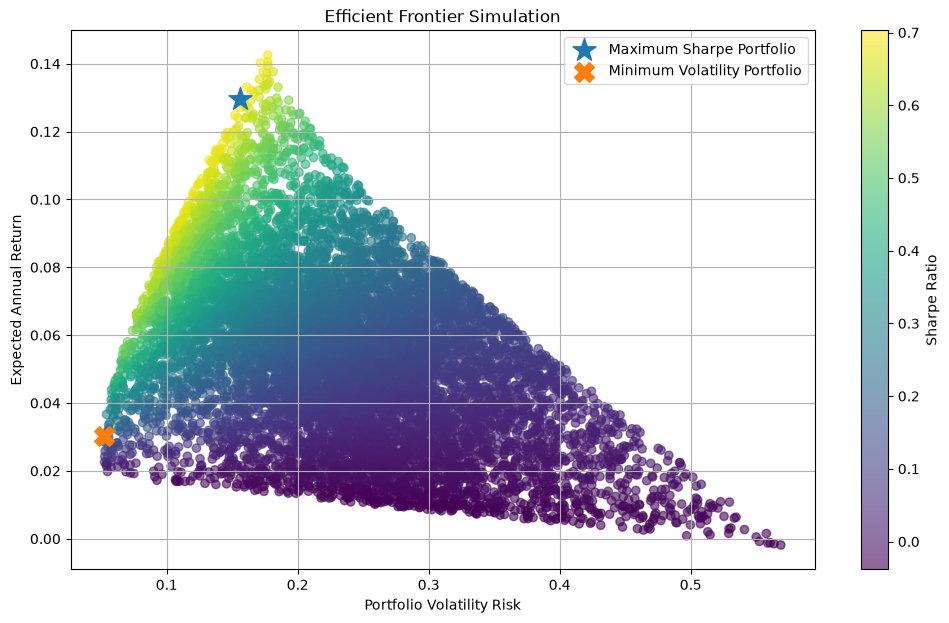

In [14]:
plt.figure(figsize=(12, 7))

plt.scatter(
    portfolio_df["Volatility"],
    portfolio_df["Expected_Return"],
    c=portfolio_df["Sharpe_Ratio"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    max_sharpe_portfolio["Volatility"],
    max_sharpe_portfolio["Expected_Return"],
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

plt.scatter(
    min_volatility_portfolio["Volatility"],
    min_volatility_portfolio["Expected_Return"],
    marker="X",
    s=200,
    label="Minimum Volatility Portfolio"
)

plt.title("Efficient Frontier Simulation")
plt.xlabel("Portfolio Volatility Risk")
plt.ylabel("Expected Annual Return")
plt.legend()
plt.grid(True)

plt.savefig("../reports/figures/efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
recommended_portfolio = max_sharpe_portfolio

recommended_portfolio

TSLA_weight        0.000699
BND_weight         0.121162
SPY_weight         0.878139
Expected_Return    0.129694
Volatility         0.156089
Sharpe_Ratio       0.702767
Name: 9736, dtype: float64

In [16]:
recommendation = pd.DataFrame({
    "Asset": ["TSLA", "BND", "SPY"],
    "Weight": [
        recommended_portfolio["TSLA_weight"],
        recommended_portfolio["BND_weight"],
        recommended_portfolio["SPY_weight"]
    ]
})

recommendation

,Asset,Weight
0,TSLA,0.000699
1,BND,0.121162
2,SPY,0.878139


In [17]:
portfolio_summary = pd.DataFrame({
    "Metric": [
        "Expected Annual Return",
        "Annual Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        recommended_portfolio["Expected_Return"],
        recommended_portfolio["Volatility"],
        recommended_portfolio["Sharpe_Ratio"]
    ]
})

recommendation.to_csv("../data/processed/recommended_portfolio_weights.csv", index=False)
portfolio_summary.to_csv("../data/processed/recommended_portfolio_summary.csv", index=False)
portfolio_df.to_csv("../data/processed/efficient_frontier_portfolios.csv", index=False)

recommendation, portfolio_summary

(  Asset    Weight
 0  TSLA  0.000699
 1   BND  0.121162
 2   SPY  0.878139,
                    Metric     Value
 0  Expected Annual Return  0.129694
 1       Annual Volatility  0.156089
 2            Sharpe Ratio  0.702767)

## Portfolio Recommendation

The recommended portfolio is the Maximum Sharpe Ratio Portfolio because it provides the best risk-adjusted return among the simulated portfolios. This means it does not simply choose the highest expected return, but instead balances expected return against volatility.

TSLA contributes growth potential based on the forecast from Task 3, while BND provides stability due to its low historical volatility. SPY provides diversified exposure to the broader market. This combination supports the Modern Portfolio Theory idea that diversification can improve the portfolio's risk-return trade-off.